# SuperMockLoad — the report panels

Reproduce the validation-report figures for a patch, mock vs bundled
observations.  Cheap panels use photometry/luminosities; the SED panels need
`seds=True`.

In [1]:
import os
# Set this to wherever the SuperMock patch files live:
os.environ['SUPERMOCK_DATA'] = '/lcrc/project/cosmo_ai/nramachandra/Projects/SPHEREx/Mocks_v3_data'

In [2]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from supermockload import SuperMock, plots

/lcrc/project/cosmo_ai/nramachandra/Projects/SPHEREx/env_jax_2025/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Densities (GSMF/LF/counts) are automatically scaled by `sm.completeness`, so they match the full sample even when downsampled.

### Cheap panels (no SEDs)

In [3]:
sm = SuperMock(3, downsample=500_000)

[SuperMock]   patch 3: 500,000 rows (of 35,996,146)
[SuperMock] ready: 500,000 galaxies, patches [3], downsampled to 500,000 (photometry/luminosities/SEDs load on demand)


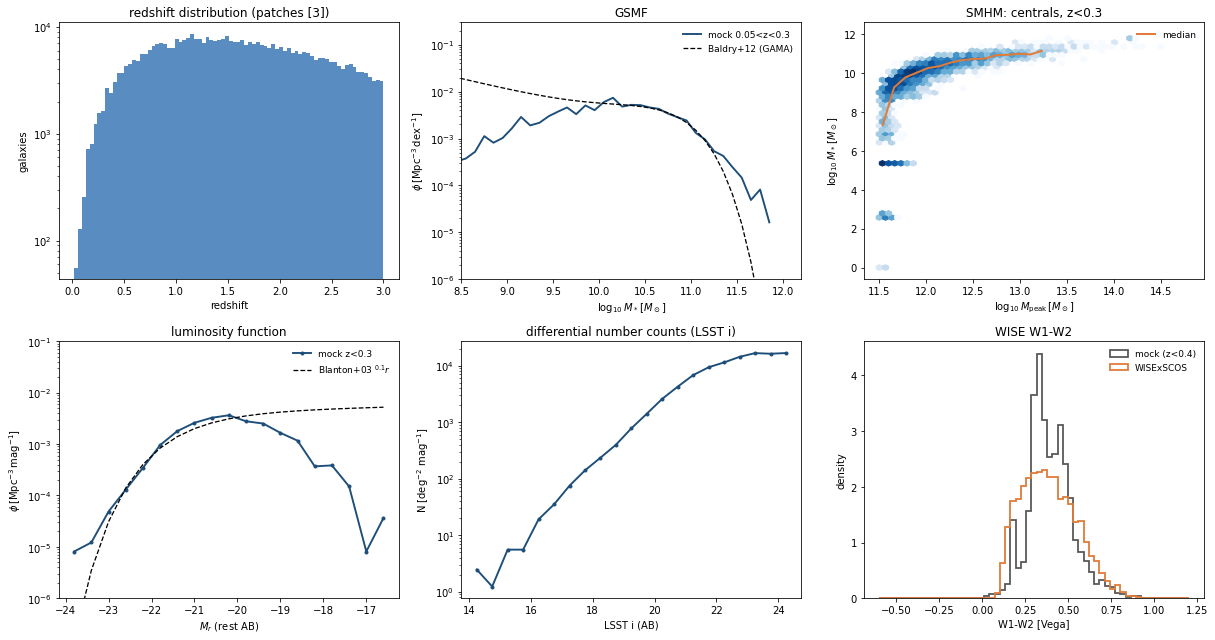

In [4]:
fig, ax = plt.subplots(2, 3, figsize=(17, 9))
plots.redshift_distribution(sm, ax=ax[0, 0])
plots.gsmf(sm, ax=ax[0, 1])
plots.smhm(sm, ax=ax[0, 2])
plots.luminosity_function(sm, ax=ax[1, 0])
plots.number_counts(sm, ax=ax[1, 1], survey='LSST', band='i')
plots.wise_w1w2(sm, ax=ax[1, 2])
fig.tight_layout()

### Histories & SPHEREx spectrophotometry
MAH/SFH need the 2-D fields; SPHEREx shows the 102-channel low-res spectrum.

[SuperMock]   patch 3: 200,000 rows (of 35,996,146)
[SuperMock] ready: 200,000 galaxies, patches [3], downsampled to 200,000 (photometry/luminosities/SEDs load on demand)


/lcrc/project/cosmo_ai/nramachandra/Projects/SPHEREx/env_jax_2025/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/lcrc/project/cosmo_ai/nramachandra/Projects/SPHEREx/Mocks_v3_data/SuperMockLoad/supermockload/plots.py:330: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(block, axis=0)


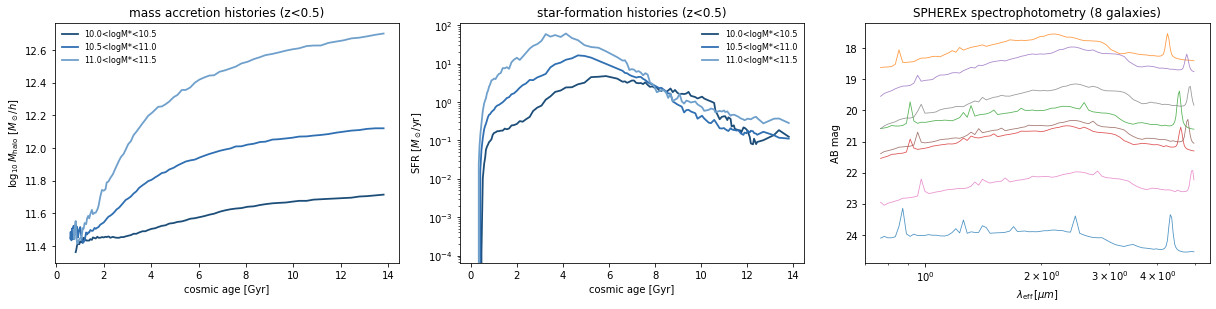

In [5]:
smh = SuperMock(3, downsample=200_000, extra_fields=('sfh', 'mah'))
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
plots.mah_tracks(smh, ax=ax[0])
plots.sfh_tracks(smh, ax=ax[1])
plots.spherex_spectra(smh, ax=ax[2])
fig.tight_layout()

### Optical colours vs SDSS / DEEP2 (density contours)
Mock colours are LSST ugriz (a close SDSS-filter proxy), restricted to each survey's z-range.

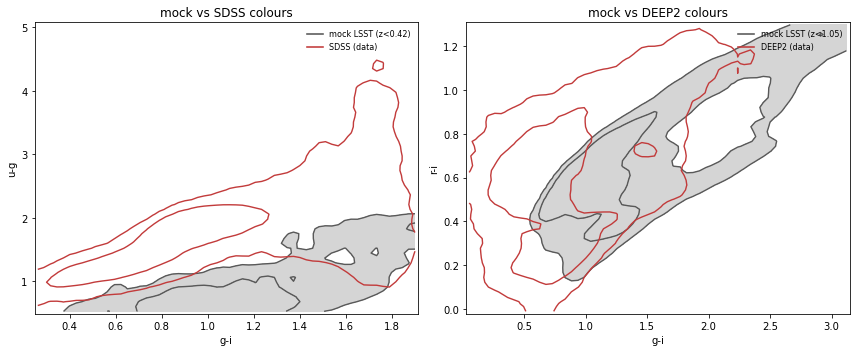

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plots.optical_colors(sm, ax=ax[0], survey='SDSS', cx='g-i', cy='u-g')
plots.optical_colors(sm, ax=ax[1], survey='DEEP2', cx='g-i', cy='r-i')
fig.tight_layout()

### SED panels

Open with `seds=True`, then the WISE colours (W2−W3 needs W3/W4 from SEDs),
GAMA stacks, and example SEDs.  The WISE panel projects a mock SED subsample
through the real WISE RSRs.

In [7]:
sm_sed = SuperMock(3, downsample=300_000, seds=True)

[SuperMock]   patch 3: 300,000 rows (of 35,996,146)
[SuperMock]   SED row alignment verified (core_tag)
[SuperMock] ready: 300,000 galaxies, patches [3], downsampled to 300,000 (photometry/luminosities/SEDs load on demand)


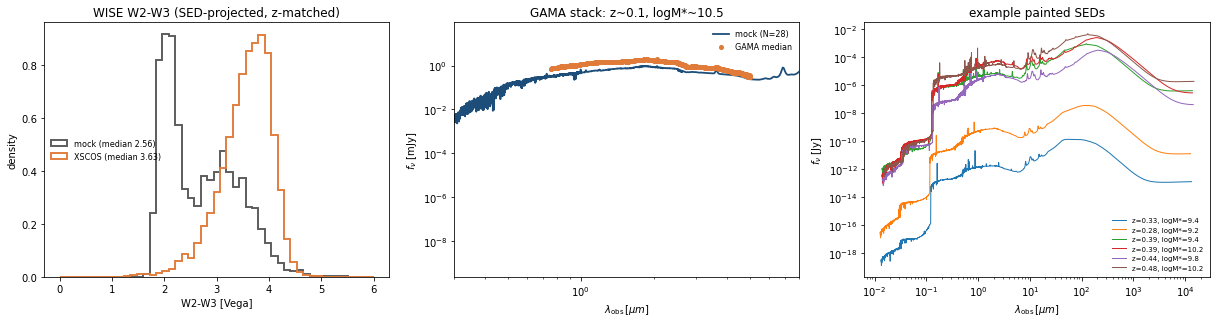

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
plots.wise_colors(sm_sed, ax=ax[0], n=3000)
plots.gama_stacks(sm_sed, ax=ax[1], z0=0.1, logm=10.5)
plots.example_seds(sm_sed, ax=ax[2])
fig.tight_layout()

On the WISE W2−W3 offset: XSCOS is W3+W4-detected (star-forming-biased), while a W1-selected mock keeps quiescent galaxies, so the mock median sits bluer. It is a selection effect, not a model error.

### One-call summary grid — every modality

`plots.report` lays out all panels at once. Include `extra_fields=('sfh','mah')`
for the MAH/SFH panels and `seds=True` for the SPHEREx/WISE/GAMA/SED panels.

[SuperMock]   patch 3: 200,000 rows (of 35,996,146)
[SuperMock]   SED row alignment verified (core_tag)
[SuperMock] ready: 200,000 galaxies, patches [3], downsampled to 200,000 (photometry/luminosities/SEDs load on demand)


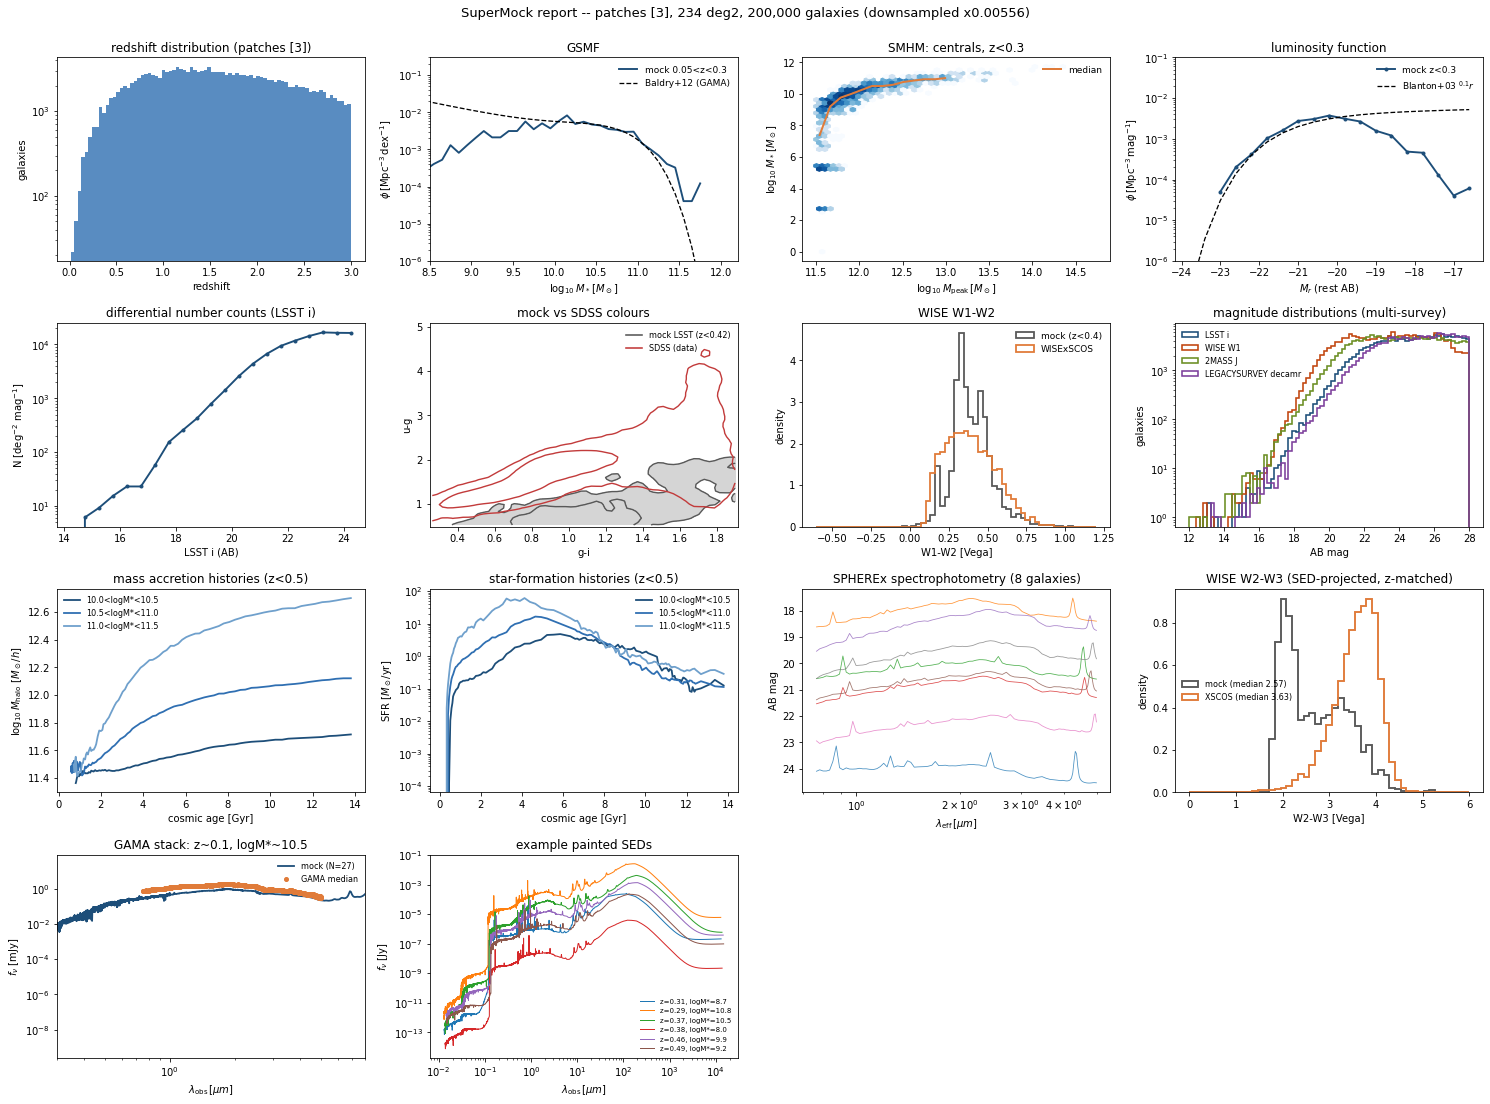

In [9]:
sm_all = SuperMock(3, downsample=200_000, seds=True, extra_fields=('sfh', 'mah'))
fig = plots.report(sm_all, seds=True)